<a href="https://colab.research.google.com/github/AIPI510/aipi510-fall24/blob/lecture-code/week_5_lecture_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis Example

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the survey dataset
survey_df = pd.read_csv('./data/surveys.csv')

# Load the participants dataset
participants_df = pd.read_csv('./data/participants.csv')

# Survey Data Pivoted To Capture *presumed* entire survey and use question, `scale`, as feature

survey_df = survey_df.sort_values(
    ["user_code", "created_at", "scale"]
).copy()

survey_df["session_number"] = (
    survey_df.groupby(
        ["user_code", "created_at", "scale"]
    )
    .cumcount()
    .add(1)
)

survey_scale_df = (
    survey_df.pivot(
        index=["user_code", "created_at", "session_number"],
        columns="scale",
        values="value",
    )
    .reset_index()
    .rename_axis(columns=None)
    .sort_values(["user_code", "created_at", "session_number"])
    .reset_index(drop=True)
)

print(survey_scale_df)


      user_code  created_at  session_number  S_CORONA  S_COVID_BLUISH  \
0    01bad5a519  2020-04-23               1       2.0             1.0   
1    01bad5a519  2020-04-25               1       NaN             1.0   
2    01bad5a519  2020-04-27               1       NaN             1.0   
3    01bad5a519  2020-04-29               1       NaN             1.0   
4    01bad5a519  2020-05-03               1       NaN             1.0   
..          ...         ...             ...       ...             ...   
332  fde84801d8  2020-05-10               1       NaN             1.0   
333  fde84801d8  2020-05-14               1       NaN             1.0   
334  fde84801d8  2020-05-16               1       NaN             1.0   
335  fe6c1b1349  2020-05-07               1       1.0             NaN   
336  fe6c1b1349  2020-05-12               1       NaN             1.0   

     S_COVID_BREATH  S_COVID_CONFUSION  S_COVID_COUGH  S_COVID_FATIGUE  \
0               3.0                1.0           

## Questions we are asking:
* What are the dimensions of the dataset (number of rows and columns)?
* What are the data types of the variables (numerical, categorical, text, etc.)?
* Are there any missing values, and if so, how are they represented?


In [3]:
# Survey Data Structure
print("Survey Data Structure")
print("---------------")
print(f"Survey Dimensions: {survey_df.shape}")
print(f"Survey Data Types:\n{survey_df.dtypes}")
print(f"Survey Missing Values:\n{survey_df.isnull().sum()}")

# Participants Data Structure
print("Participants Data Structure")
print("---------------")
print(f"Participants Dimensions: {participants_df.shape}")
print(f"Participants Data Types:\n{participants_df.dtypes}")
print(f"Participants Missing Values:\n{participants_df.isnull().sum()}")


Survey Data Structure
---------------
Survey Dimensions: (2259, 6)
Survey Data Types:
user_code         object
scale             object
created_at        object
value              int64
text              object
session_number     int64
dtype: object
Survey Missing Values:
user_code         0
scale             0
created_at        0
value             0
text              0
session_number    0
dtype: int64
Participants Data Structure
---------------
Participants Dimensions: (185, 8)
Participants Data Types:
user_code          object
gender             object
age_range          object
city               object
country            object
height            float64
weight            float64
symptoms_onset     object
dtype: object
Participants Missing Values:
user_code          0
gender             0
age_range          0
city              12
country            6
height             2
weight             0
symptoms_onset    38
dtype: int64


## Interpretation

### Survey Data

This indicates that there are 2259 survey responses, and the features of scale, created_at, vlaue and text that represent individual entries in a larger survey object.

The dataset is complete, and no imputation or deletion of rows/columns is necessary. If I had to venture a guess, I'd imagine field valdiation prevented users from submitting surveys with empty responses or the data has already been pre-processed. Since these entries are meant to represent user feedback, I would be uncomfortable imputing any missing values

### Participant Data

This data set includes a user_code, just like the survey data and hopefully reliaby maps to a single user across data sets. This time we do have columns with missing values such as city, symptom onset date, country and height. Once again, I do not feel that these values are safe to impute as they should map back to a single individual who may not be accurately described using calculated values such as mean or most common values.

## Questions we are asking:
* What are the central tendency measures (mean, median, mode) for numerical variables?
* What are the measures of dispersion (range, variance, standard deviation) for numerical variables?
* What is the distribution of the variables (normal, skewed, etc.)?


In [4]:
# Descriptive Statistics
# Only checking in the participants data set as the survey response numerical 
# values map to different questions and do not seem like they would make sense 
# aggregated.
print("\nDescriptive Statistics")
print("----------------------")
numeric_columns = participants_df.select_dtypes(include=[np.number]).columns
print("Central Tendency Measures:")
print(participants_df[numeric_columns].describe().loc[['mean', '50%']])
print("\nDispersion Measures:")
print(participants_df[numeric_columns].describe().loc[['std', 'min', 'max']])

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures:")
print("------------------------")
print(participants_df[numeric_columns].skew())
print(participants_df[numeric_columns].kurt())


Descriptive Statistics
----------------------
Central Tendency Measures:
          height     weight
mean  169.976393  77.927757
50%   168.000000  74.344000

Dispersion Measures:
         height      weight
std   12.400103   19.552541
min  132.080000   43.500000
max  250.000000  154.221000

Distribution Measures:
------------------------
height    2.910275
weight    0.865345
dtype: float64
height    17.552808
weight     0.891368
dtype: float64


## Interpretation

#### Descriptive Statistics
The mean height of a survey participant was about 170 centimeters and the average weight about 78 kilograms. The average height in our data set aligns well with the average male human height. The average weight skews heavier than the global average but lower than the North American average which leads me to draw the conclusion that our globalized representation is quite good.

### Dispersion Measures
When looking at the min/max values for `height`, the max value of 250cm immediately stands out to me as unreasonable for a human. 132cm as the minimum value does seem reasonable to me. I'm hesitant to consider 154kg an unreasonably large weight for a human, but I'd want to take a look at that specific entry before discarding it to see if there are any indicators of an incorrect unit of measurement being applied by the end user.

#### Distribution Measures
The `height` value has a skew of 2.91 indicating a heavier left tail. Additionally, with a kurtosis value of 17.5 it seems our height column is inclined to have extreme outliers present.

Meanwhile, `weight` has a sub-zero skew value indicating a heavier right tail as well as a sub-zero kurtosis value which indicates less likely presence of extreme outliers.


## Questions we are asking:
* Are there any duplicated rows or inconsistent values?
* Are there any outliers or extreme values that need attention?
* Do the values make sense based on the context and domain knowledge?


In [5]:
# Data Quality
print("\nData Quality")
print("------------")
print(f"Survey Duplicated Rows: {survey_df.duplicated().sum()}")
print(f"Participants Duplicated Rows: {participants_df.duplicated().sum()}")
print("Checking for Inconsistent Values Survey:")
print(survey_df.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))
print("Checking for Inconsistent Values Participants:")
print(participants_df.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))



Data Quality
------------
Survey Duplicated Rows: 0
Participants Duplicated Rows: 0
Checking for Inconsistent Values Survey:
                            most_frequent_value
user_code                            6be5033971
scale                           S_COVID_FATIGUE
created_at                           2020-05-03
value                                         1
text            User isn’t experiencing symptom
session_number                                1
Checking for Inconsistent Values Participants:
               most_frequent_value
user_code               007b8190cf
gender                           f
age_range                    35-44
city                        Moscow
country                     Russia
height                       168.0
weight                        60.0
symptoms_onset            5/6/2020


## Interpretation

Duplicated Rows: There are no duplicated rows in the dataset.


Inconsistent Values: Most frequent values for each column. This helps identify any potential inconsistencies or anomalies. For example, if an unusually high frequency is observed for a specific value, it might indicate an issue with data collection or entry.

## Questions we are asking:

* Is there any correlation between pairs of numerical variables?
* Are there any noticeable patterns or trends in the data?
* How are categorical variables related to numerical variables?



 Pariticpants Variable Relationships
----------------------
Correlation Matrix:
          height    weight
height  1.000000  0.227413
weight  0.227413  1.000000


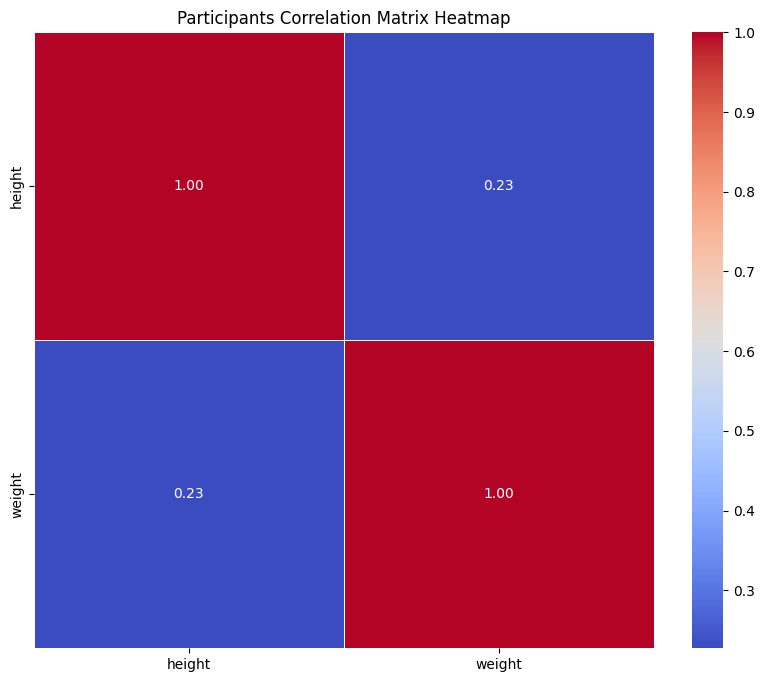


 Survey Scale Mean Grouped Variable Relationships
----------------------
Correlation Matrix:


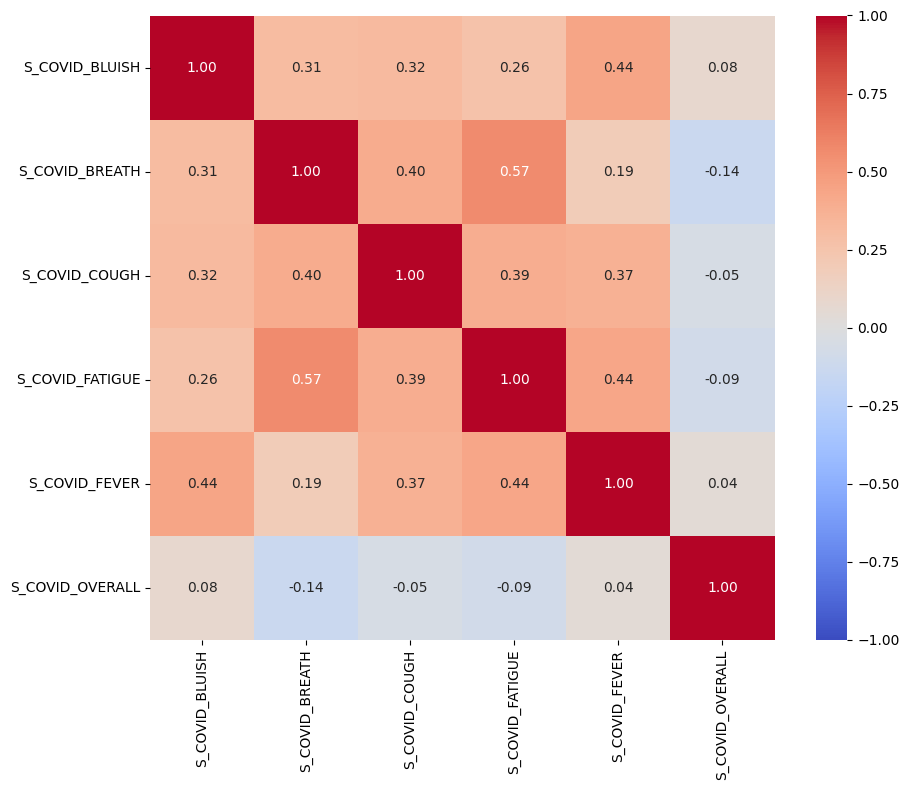

In [ ]:
# Variable Relationships
print("\n Pariticpants Variable Relationships")
print("----------------------")
print("Correlation Matrix:")
participants_correlation_matrix = participants_df[numeric_columns].corr()
print(participants_correlation_matrix)

# Visualize the Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(participants_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Participants Correlation Matrix Heatmap')
plt.show()

# Symptom Relationships
print("\n Survey Symptom Scale Mean Grouped Variable Relationships")
print("----------------------")
print("Correlation Matrix:")

scale_cols = [
    "S_COVID_BLUISH",
    "S_COVID_BREATH",
    "S_COVID_COUGH",
    "S_COVID_FATIGUE",
    "S_COVID_FEVER",
    "S_COVID_OVERALL",
]

heatmap_df = survey_scale_df[scale_cols]

plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
)

plt.tight_layout()
plt.show()


## Interpretation

I am surprised to see an inverse correlation between weight and height. This prompts me further to investigate if there may have been some conversion errors at data collection time possibly from requiring users to input values in units of measurement they are not familiar with.

I did not map correlations for the raw survey results df because the labels serve to map individual question/responses. I created a df in which one row maps to an entire survey to see how scores across symptoms mapped to each other. The strongest correlation is between fatigue and shortness of breath, which makes sense. 

## Questions we are asking:

* How can the variables be visualized effectively (histograms, scatterplots, box plots, etc.)?
* Do the visualizations reveal any interesting patterns or insights?
* Are there any subgroups or clusters that can be identified visually?


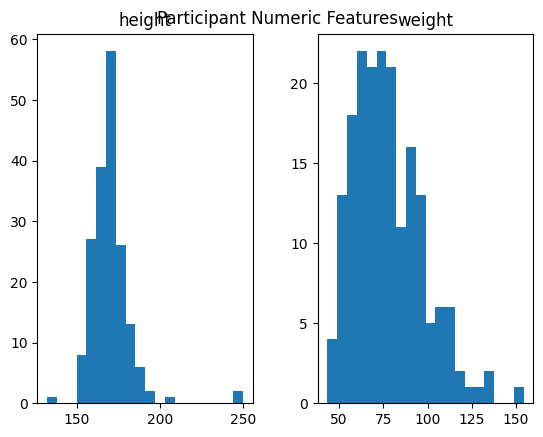

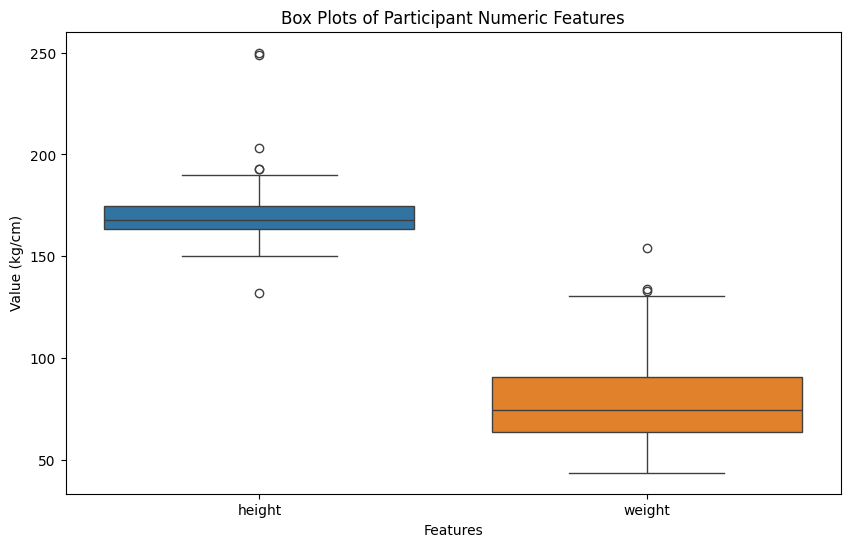

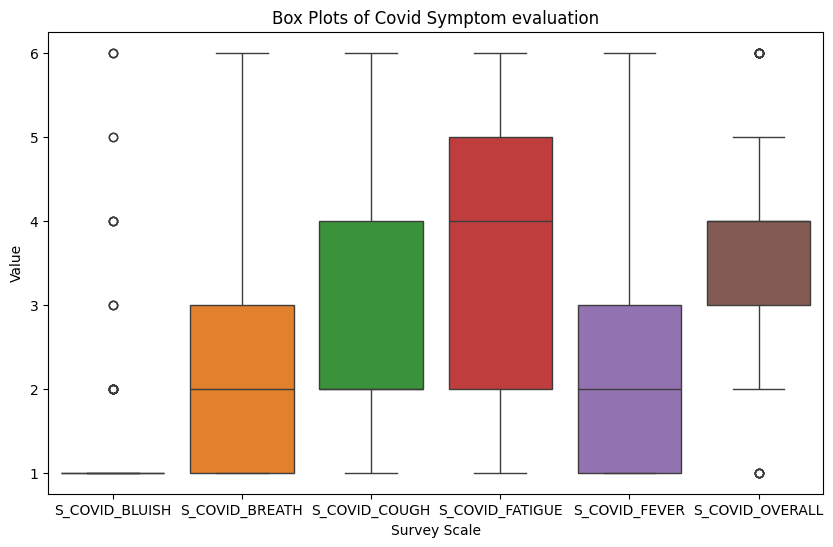

In [ ]:
# Visualize distributions
participants_df[numeric_columns].hist(bins=20, grid=False)
plt.suptitle('Participant Numeric Features', y=0.93)
plt.show()

# Box plots to identify outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=participants_df[numeric_columns])
plt.title('Box Plots of Participant Numeric Features')
plt.xlabel('Features')
plt.ylabel('Value (kg/cm)')
plt.show()

# Box plots to look at response ranges across COVID symptom questions
covid_symptom_df = survey_scale_df[scale_cols]
plt.figure(figsize=(10, 6))
sns.boxplot(data=covid_symptom_df)
plt.title('Box Plots of Covid Symptom evaluation')
plt.xlabel('Survey Scale')
plt.ylabel('Value')
plt.show()

## Questions we are asking:

* Are there any new features that can be derived from the existing ones?
* Is there a need to transform or scale any variables?
* Are there any variables that can be combined or decomposed?



Feature Engineering
-------------------
New Features: Index(['S_COVID_BLUISH', 'S_COVID_BREATH', 'S_COVID_COUGH', 'S_COVID_FATIGUE',
       'S_COVID_FEVER', 'S_COVID_OVERALL', 'perceived_severity'],
      dtype='object')
New Features: <bound method NDFrame.head of      S_COVID_BLUISH  S_COVID_BREATH  S_COVID_COUGH  S_COVID_FATIGUE  \
0               1.0             3.0            2.0              1.0   
1               1.0             1.0            2.0              1.0   
2               1.0             2.0            2.0              1.0   
3               1.0             1.0            2.0              1.0   
4               1.0             1.0            1.0              2.0   
..              ...             ...            ...              ...   
332             1.0             2.0            4.0              2.0   
333             1.0             1.0            2.0              1.0   
334             1.0             1.0            2.0              1.0   
335             NaN     

/var/folders/wv/nbn988353cz5x3vm10jh3g3h0000gn/T/ipykernel_34168/3600739475.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  covid_symptom_df['perceived_severity'] = survey_scale_df[symptom_cols].mean(axis=1)


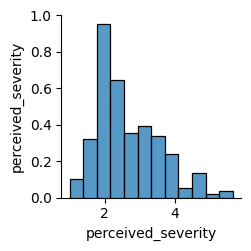

In [19]:
# Feature Engineering
print("\nFeature Engineering")
print("-------------------")

symptom_cols = [
    "S_COVID_BLUISH",
    "S_COVID_BREATH",
    "S_COVID_COUGH",
    "S_COVID_FATIGUE",
    "S_COVID_FEVER",
    "S_COVID_OVERALL",
]

covid_symptom_df['perceived_severity'] = survey_scale_df[symptom_cols].mean(axis=1)
print(f"New Features: {covid_symptom_df.columns}")
print(f"New Features: {covid_symptom_df.head}")

# Visualize new features
sns.pairplot(covid_symptom_df, vars=['perceived_severity'])
plt.show()

## Interpretation

#### New Features (Perceived Severity):
My engineered feature was the percieved severity of the COVID experience for the user by using averaging the score of the symptoms across the idenitified COVID symtpom columns. This assumes equal weight applied to each symptom which may be misleading. For example, fatigue and shortness of breath, while both unpleasant may not necessarily cause the same amount of "misery" for a user. The subjective nature of perception makes this a risky feature to put any real significance on.